In [103]:
import numpy as np
import networkx as nx
import pandas as pd
import pickle
import random
from sklearn.model_selection import train_test_split


def save_dict_to_pickle(dictionary, filename):
    import os
    print(f'Saving the dictionary to {filename}...')
    # Extract the directory path from the filename
    directory = os.path.dirname(filename)
    
    # Create the directory if it doesn't exist
    if not os.path.exists(directory):
        os.makedirs(directory)

    # Save the dictionary to the pickle file
    with open(filename, 'wb') as file:
        pickle.dump(dictionary, file)
    print('Saving complete...')

def load_dict_from_pickle(filename):
    with open(filename, 'rb') as file:
        loaded_dict = pickle.load(file)
    return loaded_dict

In [104]:
# patient_admissions = load_dict_from_pickle('../Data/patient_admissions.pkl')
admission_diagnoses = load_dict_from_pickle('../Data/admission_diagnoses.pkl')
# admission_procedures = load_dict_from_pickle('../Data/admission_procedures.pkl')
# admission_medications = load_dict_from_pickle('../Data/admission_medications.pkl')

### Patient-based simulation

In [106]:
patients = [p for p in patient_admissions]
print(len(patients))

num_Patients = 15
sample_of_patients = random.sample(patients, num_Patients)

train_patients, test_patients = train_test_split(sample_of_patients, test_size=0.2, random_state=42)

print("Training Data:", len(train_patients))
print("Testing Data:", len(test_patients))


46520
Training Data: 12
Testing Data: 3


In [107]:
train_data, test_data = {}, {}

for p in train_patients:
    visit = {}
    for v in patient_admissions[p]:
        D, R, M = [], [], []
        if v in admission_diagnoses:
            D = admission_diagnoses[v]
        if v in admission_procedures:
            R = admission_procedures[v]
        if v in admission_medications:
            M = admission_medications[v]
        visit[v] = {'diagnoses': D, 'procedures': R, 'medications': M}
    train_data[p] = visit
        

for p in test_patients:
    visit = {}
    for v in patient_admissions[p]:
        D, R, M = [], [], []
        if v in admission_diagnoses:
            D = admission_diagnoses[v]
        if v in admission_procedures:
            R = admission_procedures[v]
        if v in admission_medications:
            M = admission_medications[v]
        visit[v] = {'diagnoses': D, 'procedures': R, 'medications': M}
    test_data[p] = visit
        



In [108]:
# Procedure here as follow:
# for each patient in the test set, create new set for diagnoses where we identify a random location, 
# remove item at that location, and keep a record of that location in another data structure.


import random

# Example list
my_list = [1, 2, 3, 4, 5]

def remove_random_item(L):
    '''get 
        - removed item, 
        - its index, 
        - the new list after removal
        - LHS_item: left neighbor
        - RHS_item: right neighbor'''
    # Generate a random index
    random_index = random.randint(1, len(L) - 2)
    LHS = random_index - 1
    RHS = random_index + 1
    
    LHS_item = L[LHS]    
    RHS_item = L[RHS]    

    # Remove the item at the random index and print it
    removed_item = L.pop(random_index)
    
    return {'removed_item': removed_item, 'loc': random_index, 'List': L, 'L_item': LHS_item, 'R_item': RHS_item}

remove_random_item(my_list)

{'removed_item': 3, 'loc': 2, 'List': [1, 2, 4, 5], 'L_item': 2, 'R_item': 4}

# Dynamic Time Wrapping (DTW)

In [109]:
import numpy as np
import matplotlib.pyplot as plt

from dtw import *
from copy import deepcopy


def maps(l1, l2):
    '''creates a dictionary where the unique elements of l1 become keys, 
    and their corresponding values are lists of elements from l2 
    THAT SHARE THE SAME INDEX...'''
    
    D = {}
    for i in range(len(l1)):
        if l1[i] not in D.keys():
            D[l1[i]] = []

        D[l1[i]].append(l2[i])

    return D


def viz(Q, T, ind1, ind2, fname):
    # Convert to numpy arrays for ease of indexing
    Q = np.array(Q)
    T = np.array(T)

    # Plot the query and template signals with alignment lines
    plt.figure(figsize=(12, 6))
    plt.plot(range(len(Q)), Q, 'r-', label='Query Signal')
    plt.plot(range(len(T)), T, 'b-', label='Template Signal')

    # Plot the alignment lines
    for i, j in zip(ind1, ind2):
        plt.plot([i, j], [Q[i], T[j]], 'k-', alpha=0.5)

    plt.scatter(ind1, Q[ind1], color='red')
    plt.scatter(ind2, T[ind2], color='blue')

    # Labeling the plot
    plt.xlabel('Index')
    plt.ylabel('Signal Value')
    plt.legend()
    plt.title('DTW Alignment')

    plt.tight_layout()
    # plt.savefig(fname, dpi = 300)
    plt.show()


def compute_missing_ranges(M, D):
    """
    Compute the missing ranges in M based on D.

    Parameters:
    - M: Dictionary where keys are tuples representing pairs of indices and values are lists to store ranges.
    - D: Dictionary where keys are indices and values are lists of indices from another list.

    Returns:
    - Updated M dictionary with computed ranges appended to each key's list.
    """

    for p in M:

        start = min(D[p[0]]) + 1
        end = max(D[p[1]])
        M[p].extend([r for r in range(start, end)])

    return M


dist = lambda x, y: 0 if x == y else 1

In [110]:
test_p  = random.sample(test_patients, 1)[0] 
train_p = random.sample(train_patients,1)[0]

query    = test_data [test_p] [patient_admissions[test_p][0]]['diagnoses']
template = train_data[train_p][patient_admissions[train_p][0]]['diagnoses']

print('query: ', query)
print('template: ', template)


# Find the best match with the canonical recursion formula
alignment = dtw(query, template, dist)
cost, _, _, (query_ind, template_ind) = deepcopy(alignment)



print('cost: ', cost)
print ('query_ind: ', query_ind)
print ("template_ind: ", template_ind)

print('----------------------------------------------------------------------------------')

dic_qt = maps(query_ind, template_ind)
print ('mapping: ', dic_qt)

dic_tq = maps(template_ind, query_ind)
print ('mapping: ', dic_tq)



query:  ['D_V30', 'D_V29', 'D_V05']
template:  ['D_008', 'D_585', 'D_403', 'D_599', 'D_041', 'D_427', 'D_428', 'D_250', 'D_V58', 'D_414', 'D_276', 'D_780', 'D_285', 'D_724', 'D_338', 'D_790', 'D_272', 'D_273', 'D_366', 'D_V45', 'D_V12']
cost:  21.0
query_ind:  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 2]
template_ind:  [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
----------------------------------------------------------------------------------
mapping:  {0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18], 1: [19], 2: [20]}
mapping:  {0: [0], 1: [0], 2: [0], 3: [0], 4: [0], 5: [0], 6: [0], 7: [0], 8: [0], 9: [0], 10: [0], 11: [0], 12: [0], 13: [0], 14: [0], 15: [0], 16: [0], 17: [0], 18: [0], 19: [1], 20: [2]}


Updated M: {(0, 1): []}


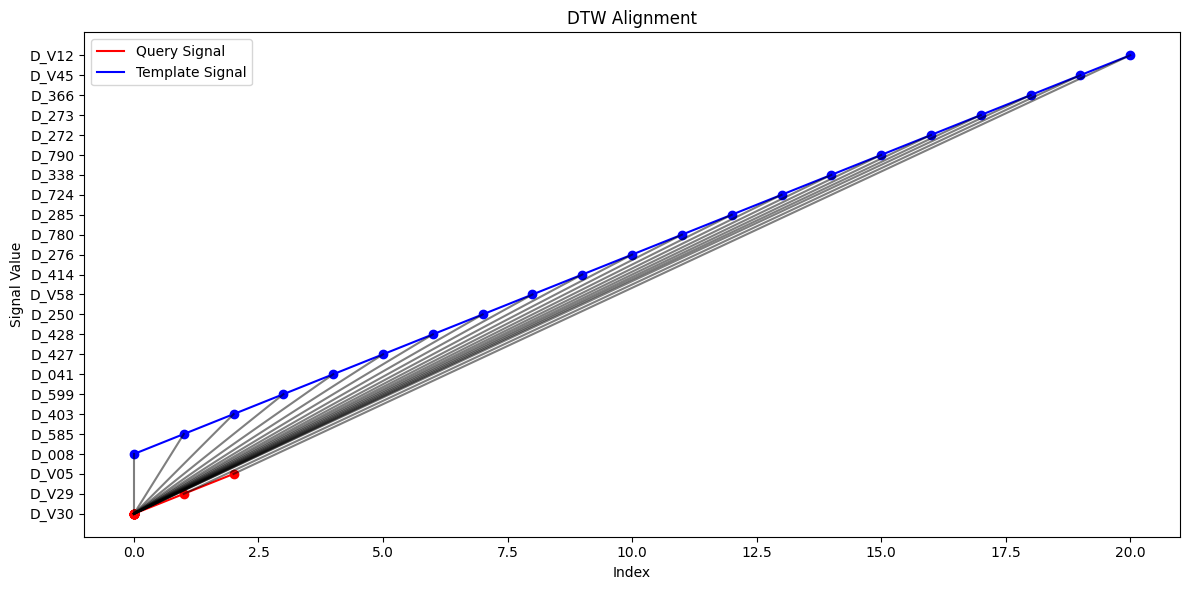

In [111]:
# # Example usage:
M_1 = {(0,1): []}
D_1_2 = {1: [2], 2: [5]}

M_1 = compute_missing_ranges(deepcopy(M_1), deepcopy(dic_tq))
print("Updated M:", M_1)

viz(query, template, query_ind, template_ind, 'DTW_Render.png')